# Downloading the Devon Ice Cap airborne magnetic survey

Accessed from https://dataverse.tdl.org/dataset.xhtml?persistentId=doi%3A10.18738%2FT8%2FEJONHJ&version=&q=&fileTypeGroupFacet=%22Text%22&fileAccess=&fileSortField=size&tagPresort=false

In [1]:
import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

## load data

Manually download the entire ZIP files from: https://dataverse.tdl.org/dataset.xhtml?persistentId=doi:10.18738/T8/EJONHJ

Unzip it and place it in `docs/data`.

In [4]:
from pathlib import Path

path = Path("../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2").glob("*")
pathfiles = [x for x in path if x.is_file()]
pathfiles

[PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018153_DEV_JKB2t_Y63a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018155_DEV_JKB2t_X57a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018151_DEV_JKB2t_X55a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018155_DEV_JKB2t_X85a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018151_DEV_JKB2t_X71a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018155_DEV_JKB2t_X77a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018153_NDEVON_JKB2t_Y5a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018158_DEV2_JKB2t_Y83a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018153_DEV_JKB2t_X99a.txt'),
 PosixPath('../data/doi-10.18738-t8-ejonhj/2018_DIC_UTIG.IMGEO2/IMGEO2_2018157_DEV_JKB2t

In [5]:
dfs = []
flights = []
for p in pathfiles:
    df = pd.read_csv(
        p,
        skiprows=58,
        sep=r"\s+",
        header=None,
        names=[
            "year",
            "day_of_year",
            "seconds_of_day",
            "lon",  # wgs 84
            "lat",  # wgs 84
            "mag_anomaly",  # filtered (2sec box car) mag anom with IGRF13 removed
            "total_mag_field",  # measured total field strength
            "field_x",  # measured x-vector field strength
            "field_y",  # measured y-vector field strength
            "field_z",  # measured z-vector field strength
            "height",  # aircraft elevation WGS84
        ],
    )
    # get flight ID from end of file name
    flight = str(p).split("_")[-1][:-4]
    if flight in flights:
        print(f"Flight {flight} is in multiple files")
    flights.append(flight)
    df["flight_id"] = flight

    dfs.append(df)
data_df = pd.concat(dfs)
data_df

Flight Y81a is in multiple files
Flight Y83a is in multiple files


,year,day_of_year,seconds_of_day,lon,lat,mag_anomaly,total_mag_field,field_x,field_y,field_z,height,flight_id
0,2018,153,21161.25,-81.532626,75.177824,-126.8,56731.5,25472.7,11468.6,56929.6,2000.13,Y63a
1,2018,153,21161.75,-81.534148,75.177912,-120.4,56727.3,953.8,117.5,59457.6,2000.48,Y63a
2,2018,153,21162.25,-81.535668,75.178000,-125.8,56727.4,815.8,-105.6,58966.5,2000.94,Y63a
3,2018,153,21162.75,-81.537185,75.178087,-127.0,56727.4,1235.7,-365.2,59055.1,2001.39,Y63a
4,2018,153,21163.25,-81.538699,75.178174,-126.9,56727.5,1167.0,-703.2,58786.3,2001.81,Y63a
...,...,...,...,...,...,...,...,...,...,...,...,...
1133,2018,155,16993.25,-83.589400,75.087646,-324.1,56622.4,5729.3,1984.6,58511.8,1802.71,X93a
1134,2018,155,16993.75,-83.589643,75.087273,-326.2,56622.0,6040.9,2406.8,58532.1,1801.74,X93a
1135,2018,155,16994.25,-83.589886,75.086899,-351.0,56621.6,6603.5,2387.3,58578.3,1800.80,X93a
1136,2018,155,16994.75,-83.590128,75.086526,-382.7,56620.9,-599.2,14422.2,57845.3,1800.09,X93a


In [6]:
data_df.flight_id.unique()

<ArrowStringArray>
[    'Y63a',     'X57a',     'X55a',     'X85a',     'X71a',     'X77a',
      'Y5a',     'Y83a',     'X99a',     'Y85a',     'X49a',     'X61a',
     'Y83b',     'X45a',     'X29a',     'Y77a',     'X83a',    'X103a',
     'Y57a',     'X76a',     'X69a',     'Y59a',     'Y47a',     'Y79a',
     'X80a',     'X89a',     'X86a',     'X67a',     'Y47b',     'Y81a',
     'X53a',     'X37a',     'Y90a',     'X72a',     'Y71a',     'Y87a',
     'X51a',     'X65a',     'Y61a',     'X78a',     'X84a',     'X73a',
     'X97a',    'X101a',     'Y75a',     'X41a',     'Y73a',     'X63a',
     'Y53a',     'X47a',     'X75a',     'X91a',     'Y69a',     'X74a',
     'Y87b',     'Y51a',     'X81a',     'Y89a',     'Y82a', 'IB95530a',
     'X59a',     'X95a',     'X33a',     'X87a',     'Y65a',     'X82a',
     'X79a',     'Y55a',     'Y49a',     'Y91a',     'Y67a',     'X93a']
Length: 72, dtype: str

In [ ]:
# make unique flight number as float for plotting
data_df["flight"] = airbornegeo.unique_line_id(data_df, line_col_name="flight_id")
data_df.flight.unique()

## Reproject

In [8]:
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.lon,
    data_df.lat,
    input_crs="EPSG:4326",
    output_crs="EPSG:3413",
)
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,mag_anomaly,total_mag_field,field_x,field_y,field_z,height,flight_id,flight,easting,northing
0,2018,153,21161.25,-81.532626,75.177824,-126.8,56731.5,25472.7,11468.6,56929.6,2000.13,Y63a,1,-960960.957930,-1.297119e+06
1,2018,153,21161.75,-81.534148,75.177912,-120.4,56727.3,953.8,117.5,59457.6,2000.48,Y63a,1,-960989.647067,-1.297086e+06
2,2018,153,21162.25,-81.535668,75.178000,-125.8,56727.4,815.8,-105.6,58966.5,2000.94,Y63a,1,-961018.289839,-1.297052e+06
3,2018,153,21162.75,-81.537185,75.178087,-127.0,56727.4,1235.7,-365.2,59055.1,2001.39,Y63a,1,-961046.929149,-1.297019e+06
4,2018,153,21163.25,-81.538699,75.178174,-126.9,56727.5,1167.0,-703.2,58786.3,2001.81,Y63a,1,-961075.499470,-1.296986e+06


## Plot data

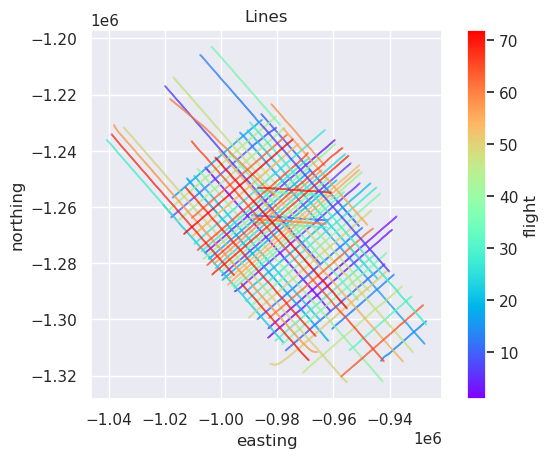

In [9]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.002,
    cmap="rainbow",
    title="Lines",
)
ax.set_aspect("equal")

In [10]:
data_df.head()

,year,day_of_year,seconds_of_day,lon,lat,mag_anomaly,total_mag_field,field_x,field_y,field_z,height,flight_id,flight,easting,northing
0,2018,153,21161.25,-81.532626,75.177824,-126.8,56731.5,25472.7,11468.6,56929.6,2000.13,Y63a,1,-960960.957930,-1.297119e+06
1,2018,153,21161.75,-81.534148,75.177912,-120.4,56727.3,953.8,117.5,59457.6,2000.48,Y63a,1,-960989.647067,-1.297086e+06
2,2018,153,21162.25,-81.535668,75.178000,-125.8,56727.4,815.8,-105.6,58966.5,2000.94,Y63a,1,-961018.289839,-1.297052e+06
3,2018,153,21162.75,-81.537185,75.178087,-127.0,56727.4,1235.7,-365.2,59055.1,2001.39,Y63a,1,-961046.929149,-1.297019e+06
4,2018,153,21163.25,-81.538699,75.178174,-126.9,56727.5,1167.0,-703.2,58786.3,2001.81,Y63a,1,-961075.499470,-1.296986e+06


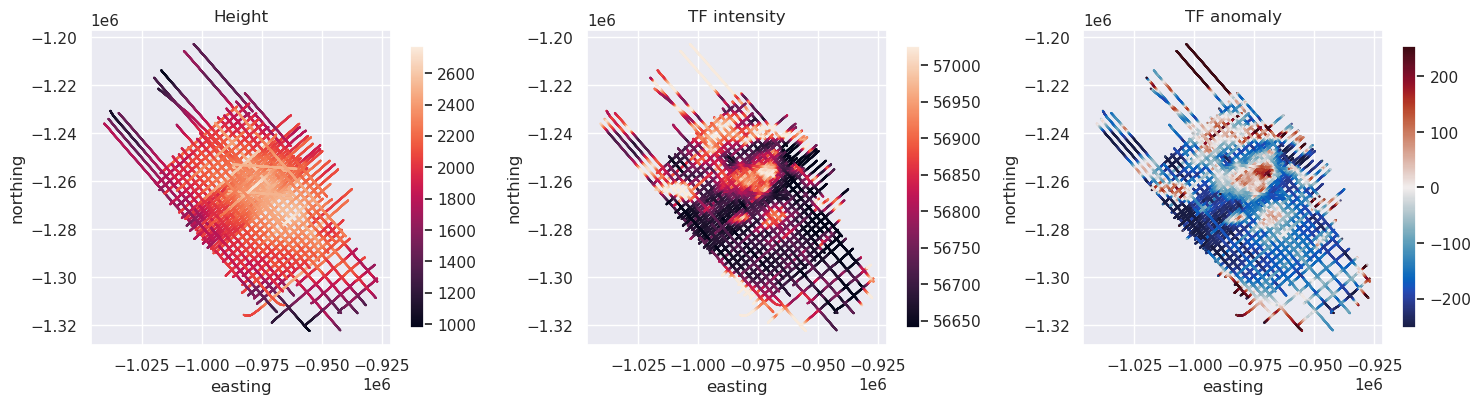

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

df = data_df

ax = df.plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    title="Height",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

cpt_lims = vd.minmax(data_df.total_mag_field, min_percentile=5, max_percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="total_mag_field",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
    title="TF intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.mag_anomaly, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="mag_anomaly",
    s=0.2,
    ax=axs[2],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="TF anomaly",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()